<a href="https://colab.research.google.com/github/mjgpinheiro/Physics_models/blob/main/Conformal_Transport_Paper1_Tokamak.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

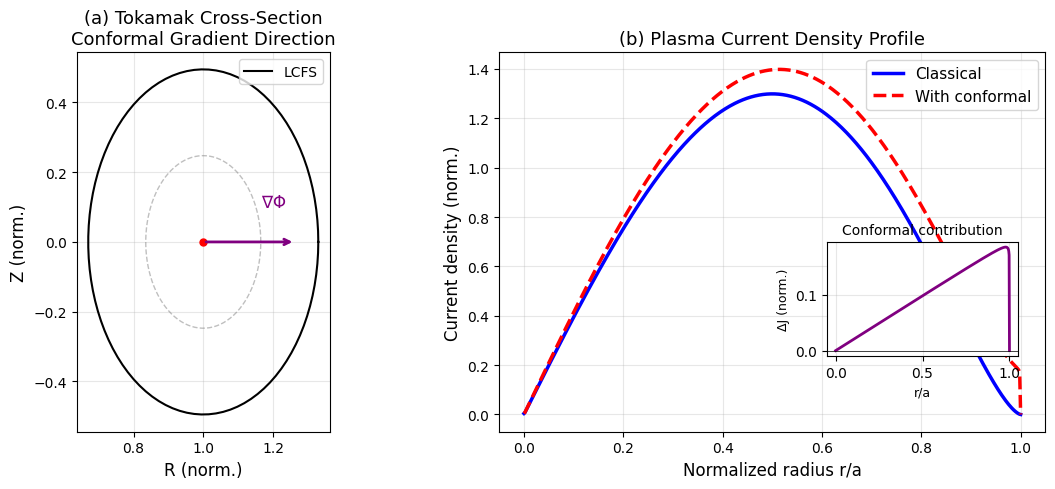

RESULTADOS NORMALIZADOS
J_classical max = 1.2990
J_conf max = 1.3983
ΔJ max = 0.1848
Rácio ΔJ/J = 14.22%


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ===========================================
# COORDENADAS NORMAIS
# ===========================================
rho = np.linspace(0, 1, 500)  # r/a normalizado
r = rho  # em unidades de a

# ===========================================
# PERFIS NORMAIS DE TOKAMAK
# ===========================================
# Densidade (parabólico)
n = (1 - rho**2)**0.5

# Temperatura (parabólico ao quadrado)
T = (1 - rho**2)**2

# Gradiente conformal (assumido radial)
grad_Phi = 2 * rho  # aumenta linearmente com r
C_eff = -0.1 * grad_Phi  # força conformal

# ===========================================
# COEFICIENTES
# ===========================================
# Eletrões muito mais móveis que iões
coeff_e = 1.0
coeff_i = 0.01

# Campo ambipolar clássico (proporcional a -∇T)
E_amb = -np.gradient(T, rho)

# ===========================================
# CORRENTES
# ===========================================
# Clássica
J_classical = n * E_amb

# Correção conformal ao campo ambipolar
delta_E_amb = (coeff_i * C_eff / (n + 0.01) - coeff_e * C_eff / (n + 0.01))
E_amb_conf = E_amb + delta_E_amb
J_conf = n * E_amb_conf

# Contribuição conformal pura
J_conf_pure = J_conf - J_classical

# ===========================================
# FIGURA
# ===========================================
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1])

# Painel (a) - Corte transversal do tokamak
ax1 = plt.subplot(gs[0])

# Desenhar secção transversal (simplificada)
R0, a = 1.0, 0.33
theta = np.linspace(0, 2*np.pi, 100)
R_lcfs = R0 + a * np.cos(theta)
Z_lcfs = a * 1.5 * np.sin(theta)
ax1.plot(R_lcfs, Z_lcfs, 'k-', linewidth=1.5, label='LCFS')

# Superfície interna
R_inner = R0 + 0.5*a * np.cos(theta)
Z_inner = 0.5*a * 1.5 * np.sin(theta)
ax1.plot(R_inner, Z_inner, 'gray', linestyle='--', linewidth=1, alpha=0.5)

# Centro
ax1.plot(R0, 0, 'ro', markersize=5)

# Indicar direção do gradiente conformal
ax1.annotate('', xy=(R0+a*0.8, 0), xytext=(R0, 0),
             arrowprops=dict(arrowstyle='->', color='purple', lw=2))
ax1.text(R0+a*0.5, 0.1, r'$\nabla \Phi$', color='purple', fontsize=12)

# Anotações
ax1.set_xlabel('R (norm.)', fontsize=12)
ax1.set_ylabel('Z (norm.)', fontsize=12)
ax1.set_title('(a) Tokamak Cross-Section\nConformal Gradient Direction', fontsize=13)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

# Painel (b) - Perfil de corrente normalizado
ax2 = plt.subplot(gs[1])

ax2.plot(rho, J_classical, 'b-', linewidth=2.5, label='Classical')
ax2.plot(rho, J_conf, 'r--', linewidth=2.5, label='With conformal')
ax2.set_xlabel('Normalized radius r/a', fontsize=12)
ax2.set_ylabel('Current density (norm.)', fontsize=12)
ax2.set_title('(b) Plasma Current Density Profile', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Inset: Efeito conformal puro
inset = ax2.inset_axes([0.6, 0.2, 0.35, 0.3])
inset.plot(rho, J_conf_pure, 'purple', linewidth=2)
inset.set_xlabel('r/a', fontsize=9)
inset.set_ylabel('ΔJ (norm.)', fontsize=9)
inset.set_title('Conformal contribution', fontsize=10)
inset.grid(True, alpha=0.3)
inset.axhline(y=0, color='k', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('fig2_tokamak_normalized.pdf', dpi=300, bbox_inches='tight')
plt.savefig('fig2_tokamak_normalized.png', dpi=300, bbox_inches='tight')
plt.show()

# ===========================================
# OUTPUT
# ===========================================
print("="*40)
print("RESULTADOS NORMALIZADOS")
print("="*40)
print(f"J_classical max = {np.max(np.abs(J_classical)):.4f}")
print(f"J_conf max = {np.max(np.abs(J_conf)):.4f}")
print(f"ΔJ max = {np.max(np.abs(J_conf_pure)):.4f}")
print(f"Rácio ΔJ/J = {np.max(np.abs(J_conf_pure))/(np.max(np.abs(J_classical))+1e-10)*100:.2f}%")
print("="*40)